# **Introduction**
In this project I analyzed the hotel booking dataset to understand patterns in customer behavior and try to predict whether a booking would be canceled or not.

Moreover, the dataset includes things like hotel type, booking time, customer details, and pricing so theres a lot of useful info in there.

Furthermore, the main goal of the project is to predict the is_canceled variable using data analysis and machine learning, and to do that i first explored the dataset and cleaned it, then made some visualizations to find patterns, and finally built multiple models so I could compare how well they perform.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
## First things first, lets explore the dataset

In [ ]:
df.shape
# We see that there are 119390 rows and 32 columns in the dataset

(119390, 32)

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
df.info()
# So there are 32 columns with most of them being int and some of them beiong objects.
# Im confused why children has a float64 datatype that feels kind of weird

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()
# explolring the summary statistics of the number columns

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.describe(include='object')
# lets explore the summary statistics of the object data tyupe columns

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [ ]:
df.isnull().sum()
# exploring the missing values
#children has 4 missing values
# country has 488 missing vlalues
# we also see that agent has 16340 and company	112593

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.nunique()
# checking how many differernt columns each column has

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [ ]:
# now lets explore the variable we are trying to predict
df['is_canceled'].value_counts()
# 0 = not canceled
# 1 = canceled
#we see that there are 75166 rows not canceled
# and we also see that there are 44224 rows who canceled

,count
is_canceled,
0,75166
1,44224


In [ ]:
df["hotel"].value_counts()
# we see that city hotel has 79330 rows
# and resort hotel has 40060 rows.
# so city hotel has almost double the amount of entries


,count
hotel,
City Hotel,79330
Resort Hotel,40060


In [ ]:
# now lets check out cancellati9ons by hotel type
pd.crosstab(df['hotel'], df['is_canceled'])
# we see that city hotel has a lot more canceled than resort hotel
# which makes sense since they have a lot more entries as well

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


In [ ]:
#checking bookings by month
df["arrival_date_month"].value_counts()

,count
arrival_date_month,
August,13877
July,12661
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


In [ ]:
# exploring cancellation by month
pd.crosstab(df["arrival_date_month"], df["is_canceled"])

is_canceled,0,1
arrival_date_month,,
April,6565,4524
August,8638,5239
December,4409,2371
February,5372,2696
January,4122,1807
July,7919,4742
June,6404,4535
March,6645,3149
May,7114,4677


In [ ]:
# lets explore the top 10 countries
df["country"].value_counts().head(10)

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
ITA,3766
IRL,3375
BEL,2342
BRA,2224


In [ ]:
# Now lets check out some important category columns
df["market_segment"].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


In [ ]:
df['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,104641
Non Refund,14587
Refundable,162


In [ ]:
df['customer_type'].value_counts()

,count
customer_type,
Transient,89613
Transient-Party,25124
Contract,4076
Group,577


In [ ]:
df["reservation_status"].value_counts()

,count
reservation_status,
Check-Out,75166
Canceled,43017
No-Show,1207


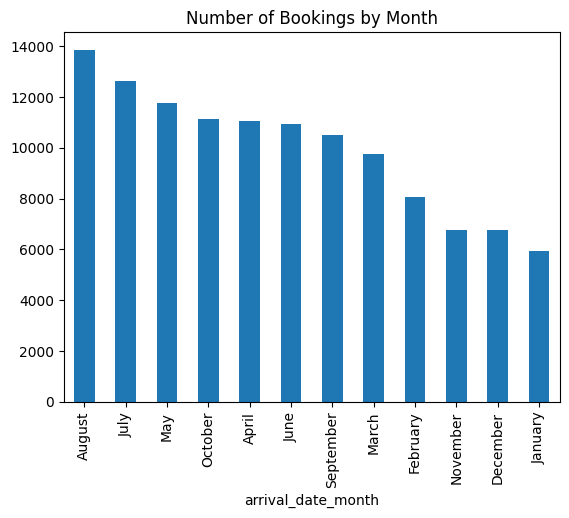

In [ ]:
df["arrival_date_month"].value_counts().plot(kind ="bar")
plt.title("Number of Bookings by Month")
plt.show()

# **Exploring the data**

so after loading the hotel booking dataset i first explored the data just to understand what im working with like the size, columns, data types, and if there are missing values
the dataset has 119390 rows and 32 columns so its pretty big and has a lot going on
the main variable for this project is is_canceled where 0 means the booking was not canceled and 1 means it was canceled
while going through the data i saw that it includes both numeric and categorical columns. some important ones are hotel, lead_time, arrival_date_month, country, market_segment, deposit_type, customer_type, adr, and total_of_special_requests which will probably be useful later
i also noticed missing values in some columns. for example children has 4 missing values, country has 488, agent has 16340, and company has 112593 missing values which is basically most of that column
then i checked the target variable and saw that 75166 bookings were not canceled while 44224 were canceled. so cancellations happen pretty often but still less than the ones that didnt cancel
i also noticed that city hotel shows up more than resort hotel and august has the highest number of bookings
so yeah this step was mainly just to understand the dataset before cleaning it and doing deeper analysis later since there are clearly some things that need to be fixed first

In [ ]:
# Now we have to clean the data
#filling missing children values with 0 because missing probably means no children
df["children"] = df["children"].fillna(0)

In [ ]:
# filling missing country values with Unknown because we dont know the country
df["country"] = df["country"].fillna("Unknown")

In [ ]:
# filling missing agent values with 0 because missing prolly means no agent was used
df["agent"] = df["agent"].fillna(0)

In [ ]:
# as we saw company has way too many missing values, so im just gonna drop it
# Dropping company or not including it in the model shouldnt have big effects on our model
df = df.drop(columns = ["company"])

In [ ]:
# romoving rows where there are 0 total guests
# a booking with nobody doesnt really make any sense
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

In [ ]:
# removing negative price rows because price per night shouldnt be negative
# would be considered as bad data
df = df[df["adr"] >= 0]

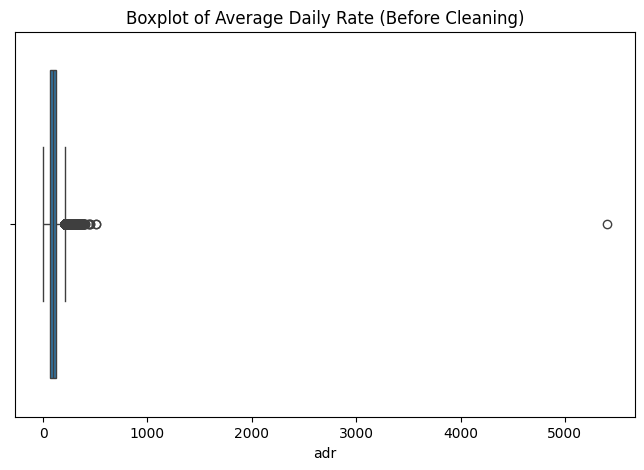

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["adr"])
plt.title("Boxplot of Average Daily Rate (Before Cleaning)")
plt.show()

In [ ]:
# from the box plot we see that surprisingly theres one singular entry where the adr is more than 1000
# we simply get rid of that row because of being an outlier
df = df[df["adr"] <= 1000]

In [ ]:
# checking the cleaned data shape
print(df.shape)

(119208, 31)


In [ ]:
# checking if missing values are fixed
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

# **Cleaning The Data**
After exploring the dataset i did some data cleaning to make the data more usable and not messy

First i handled missing values. For the children column i replaced the missing values with 0 because it will most likely just means there were no children in that booking. for the country column i filled the missing values with "Unknown" since the country wasnt provided. for the agent column i filled missing values with 0 assuming no agent was involved in those bookings.

Furthermore, the company column had over 100000 missing values which is basically most of the dataset so keeping it didnt really make sense. i just dropped it completely since it wouldnt be reliable anyway.

Moreover, i also removed rows where the total number of guests (adults + children + babies) was 0 because that doesnt really make sense for a booking to have no guests.

Then i looked at the adr column which is the price per night. I removed rows with negative values because price cant be negative. i also removed extremely high values above 1000 since those are probably outliers and would mess up the analysis and models.

So yeah these cleaning steps were mainly to make the dataset more usable before moving on to analysis and modeling since the raw data had a bunch of issues that needed to be fixed first.

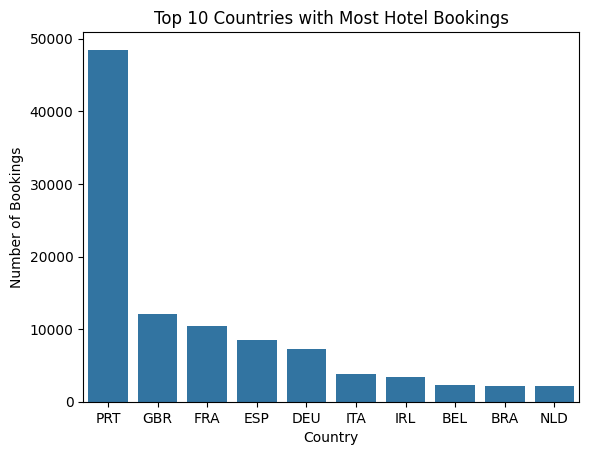

In [ ]:
# Now we move onto graphing.
# first graph - which 10 country has the most bookings

top = df["country"].value_counts().head(10)
sns.barplot(x = top.index, y = top.values)

plt.title("Top 10 Countries with Most Hotel Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")

plt.show()

# **Graph 1 Explanation**

From this graph we can see that portugal (PRT) has the highest number of hotel bookings by a huge margin compared to all the other countries

Moreover, its not even close like the bookings from portugal are way higher than countries like the UK (GBR), france (FRA), and spain (ESP)

Furthermore, this basically shows that a big portion of the dataset is coming from portugal which could affect the analysis and model results

Therefore, it kind of suggests that the dataset is more focused on customers from portugal compared to other countries which is something to keep in mind when interpreting the results.

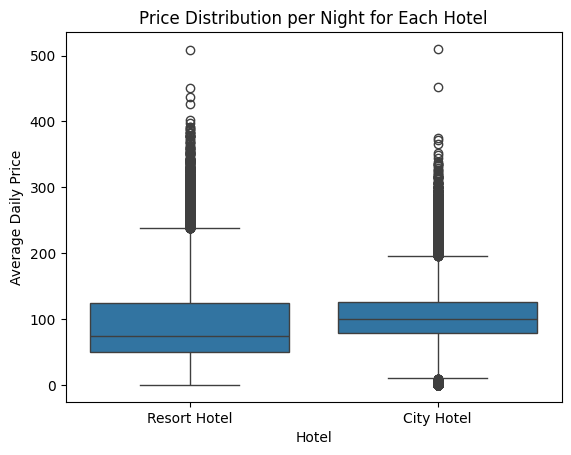

In [ ]:
# Now we do graph 2, price distribution per night for both hotels

sns.boxplot(x = "hotel", y = "adr", data =df)

plt.title("Price Distribution per Night for Each Hotel")
plt.xlabel("Hotel")
plt.ylabel("Average Daily Price")
plt.show()

# **Graph 2 Explanation**

From this boxplot we are comparing the price distribution between resort hotels and city hotels.

Moreover, we can see that city hotels usually have a slightly higher median price compared to resort hotels, so on average they tend to be a bit more expensive.

Moreover, both types of hotels have a pretty wide spread in prices and a lot of outliers, which means there are some bookings with really high prices compared to the rest, and city hotel has some really low values as well.

Furthermore, most of the prices are in a normal range but theres still a lot of variation in pricing for both hotel types, its not very consistent and kinda all over the place.

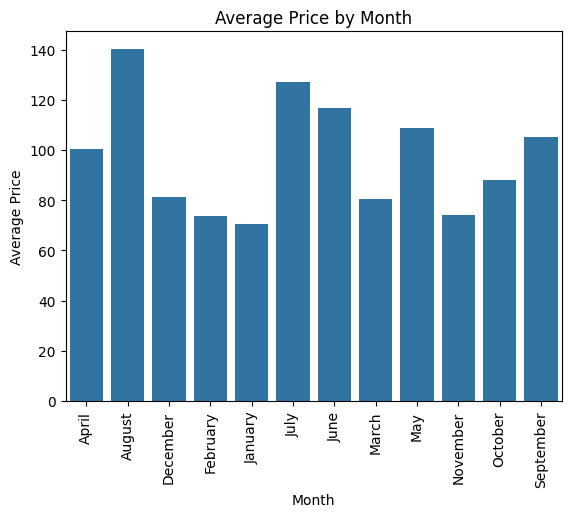

In [ ]:
# lets get into the third graph: average price per month

monthly = df.groupby("arrival_date_month")["adr"].mean()
sns.barplot(x = monthly.index, y = monthly.values)

plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation = 90)
plt.show()

# **Graph 3 Explanation**

From this graph we can see how the average price per night changes across different months.

We can see that August has the highest average price, then July and then june, so basically summer months are the most expensive

On the other, months like January, February, and November have lower average prices so they are way cheaper compared to summer.

Furthermore, this shows that hotel prices go up during peak travel seasons like in the summer and go down during off season months, like more in the winter months, which makes sense as more people are traveling in the summer so prices get pushed higher.

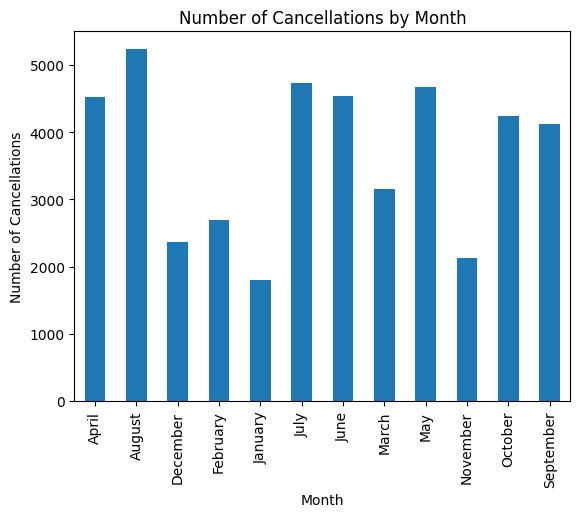

In [ ]:
# now we do graph 4 cancellations by month

cancel = pd.crosstab(df["arrival_date_month"], df["is_canceled"])

cancel[1].plot(kind = "bar")

plt.title("Number of Cancellations by Month")
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation =90)

plt.show()

# **Graph 4 Explanation**

From this graph we can see the number of cancellations for each month.

We can see that August has the highest number of cancellations, and then months like July, May, and june also have pretty high numbers.

Moreover, this basically suggests that cancellations happen more during peak travel months which are also the busiest times of the year, so it makes sense.

On the other hand, months like January and november have fewer cancellations, probably because there are just less bookings happening during those times.

So it looks like when more people book hotels, more people also end up canceling, so the two kinda go together.

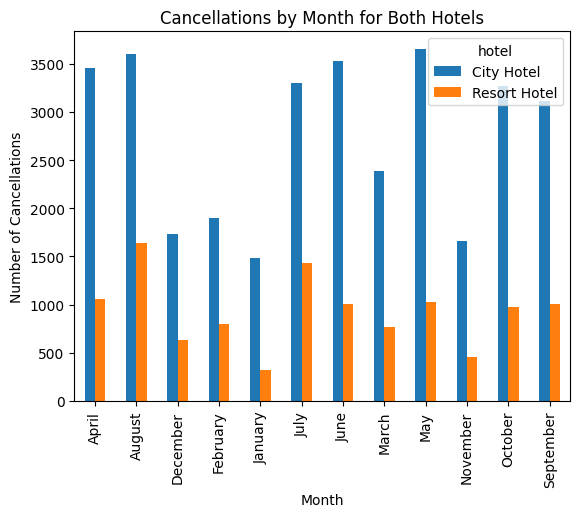

In [ ]:
#Graph 4b
# lets do the same thing for both hotels
canceled = df[df["is_canceled"] == 1]

cancel_hotels = pd.crosstab(canceled["arrival_date_month"], canceled["hotel"])
cancel_hotels.plot(kind ="bar")
plt.title("Cancellations by Month for Both Hotels")
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=90)
plt.show()

# **Graph 4b Explanation**
This graph shows the number of cancellations for each month separated by city hotel and resort hotel.

From the graph we can see that city hotel consistently has more cancellations than resort hotel in pretty much every month.

Also, the highest cancellations happen during peak months like july, august, and may for both, but the numbers are way higher for city hotel. Moreover, resort hotel follows a similar pattern but with lower cancellations.

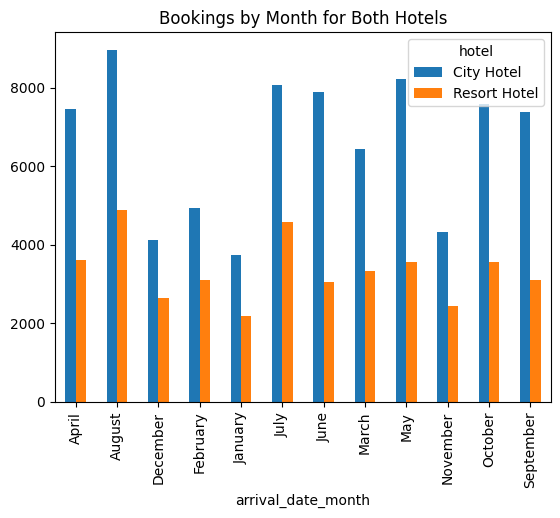

In [ ]:
# graph 4c
#bookings by month for both hotels
busy_hotels = pd.crosstab(df["arrival_date_month"], df["hotel"])

busy_hotels.plot(kind = "bar")
plt.title("Bookings by Month for Both Hotels")
plt.xticks(rotation = 90)
plt.show()

# **Graph 4c Explanation**
This graph shows the number of bookings for each month for both city hotel and resort hotel

Furthermore, city hotel has more bookings than resort hotel in every single month so its clearly more popular and the busiest months for both are july and august, with august being the highest.

So, this shows that bookings increase a lot during summer months, and city hotel consistently gets more bookings compared to resort hotel throughout the year.

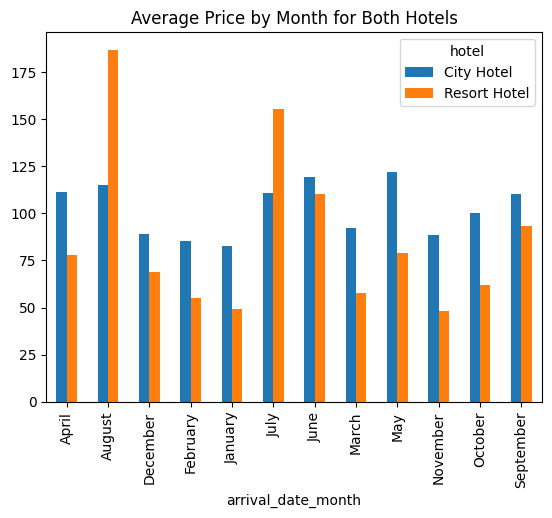

In [ ]:
# graph 4d
# price by month for both hotels
price_hotels = df.groupby(["arrival_date_month", "hotel"])["adr"].mean().unstack()

price_hotels.plot(kind = "bar")
plt.title("Average Price by Month for Both Hotels")
plt.xticks(rotation=90)
plt.show()

# **Graph 4d Explanation**

This graph shows the average price per night for each month for both city hotel and resort hotel.

Furthermore, we can see that resort hotel tends to have higher prices than city hotel during peak months like july and august and the prices go up during busy travel months and are lower during off season months.

So basically when demand increases, especially in summer, prices also increase, and resort hotels seem to charge more than city hotels during those peak times.

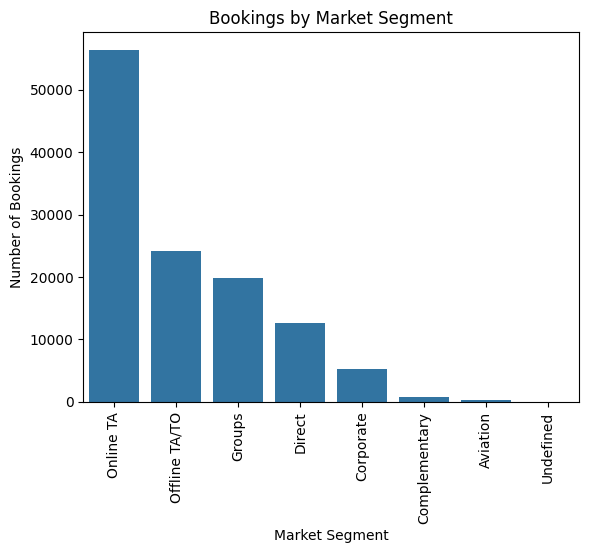

In [ ]:
# now we do graph 5, bookings by market segment

segment_counts = df["market_segment"].value_counts()
sns.barplot(x = segment_counts.index, y = segment_counts.values)

plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation = 90)

plt.show()

# **Graph 5 Explanation**

From this graph we can see that most of the hotel bookings come from the online TA, so basically travel agency segment.

Furthermore, it has way more bookings compared to all the other. After that offline TA/TO and groups are the next most common, but still not even close to online travel agency.

Then categories like corporate, complementary, and aviation have way fewer bookings compared to the others.

Furthermore, this shows that most people are booking hotels through online travel agencies instead of booking directly or using other methods.

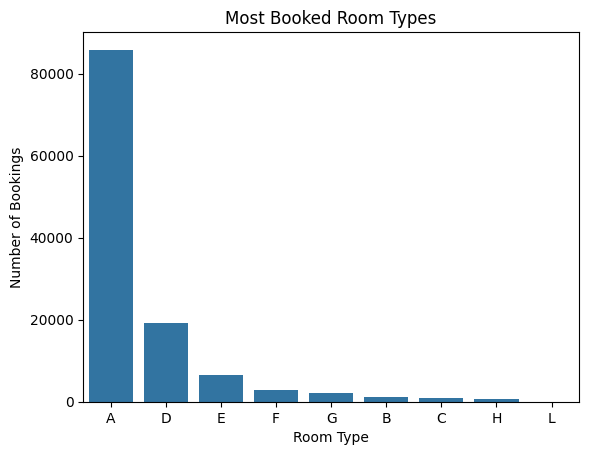

In [ ]:
# now graph 6a: most booked room types

room_counts = df["reserved_room_type"].value_counts()
sns.barplot(x = room_counts.index, y = room_counts.values)

plt.title("Most Booked Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")

plt.show()

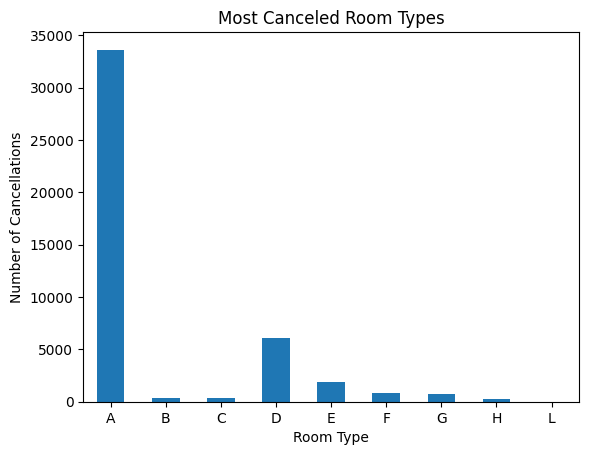

In [ ]:
# graph 6b, most canceled room types

room_cancel = pd.crosstab(df["reserved_room_type"], df["is_canceled"])
room_cancel[1].plot(kind = "bar")

plt.title("Most Canceled Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation = 0)
plt.show()

# **Graph 6a and 6b Explanations**

From these graphs we can see that room type A is by far the most commonly booked room type compared to all the others.

Moreover, it has way more bookings than the rest so its clearly the most popular one. At the same time room type A also has the highest number of cancellations.

This probably isnt anything special tho, its just because more people are booking it so naturally more people are also canceling it.

Morevoer, other room types like D and E have way fewer bookings and also fewer cancellations compared to A. So, its not really that A gets canceled more for some specific reason, its just the most booked so everything is higher for it

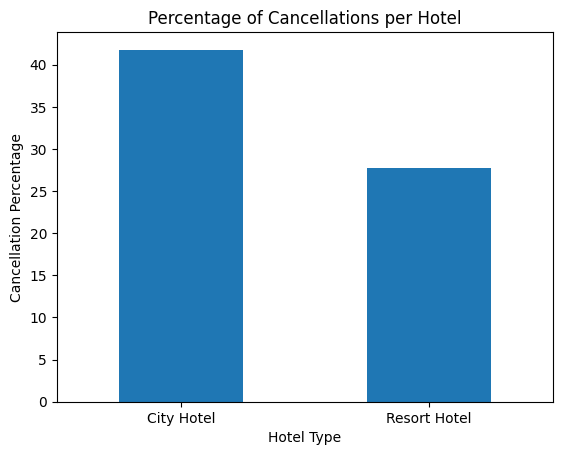

In [ ]:
# now graph 7, percentage of cancellations per hotel

percent = pd.crosstab(df["hotel"], df["is_canceled"], normalize = "index") * 100
percent[1].plot( kind = "bar")

plt.title("Percentage of Cancellations per Hotel")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Percentage")
plt.xticks(rotation=0)
plt.show()

# **Graph 7 Explanation**

From this graph we can see the percentage of bookings that were canceled for each hotel type.

City hotel have a higher cancellation rate, around 40 to 45 percent, while resort hotels are lower at around 25 to 30 percent.

So basically bookings at city hotels are more likely to get canceled compared to resort hotels.

One possible reason could be that city hotel bookings are made much more often than Resort Hotel. The data has way more rows where reservations were booked in City Hotel, so they end up having more cancellations.

So it shows a clear difference where city hotels deal with more cancellations than resort hotels

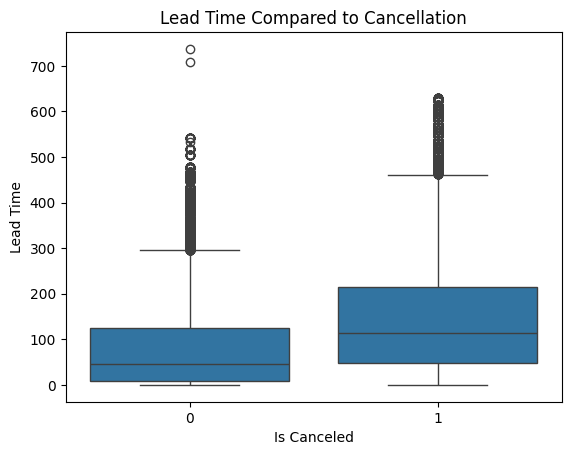

In [ ]:
#Graph 8
# lets also compare the lead time against cancellation
# checking if people who book earlier are more likely to cancel

sns.boxplot( x ="is_canceled", y = "lead_time", data = df)
plt.title("Lead Time Compared to Cancellation")
plt.xlabel("Is Canceled")
plt.ylabel("Lead Time")

plt.show()

# **Graph 8 Explanation**
From this graph we can see the relationship between lead time and whether a booking was canceled or not

Moreover, the median lead time for canceled bookings (1) is clearly higher than for non canceled bookings (0), so people who cancel usually booked further in advance

This shows that bookings made earlier are more likely to be canceled.

One possible reason coubd be that when people book realy early their plans can change over time, so theres a higher chance they end up canceling later.

So it looks like the longer the lead time, the higher the chance of cancellation.

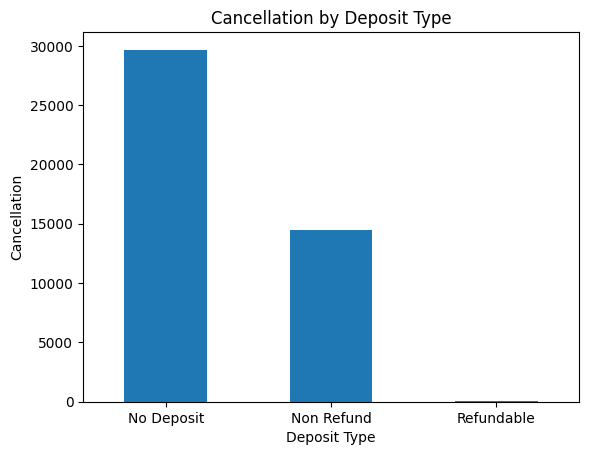

In [ ]:
# graph 9
# another important graph would be plotting deposit type againts cancellation

dc = pd.crosstab( df["deposit_type"] , df["is_canceled"])
dc[1].plot(kind = "bar")

plt.title("Cancellation by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation")
plt.xticks(rotation=0)

plt.show()

# **Graph 9**
From this graph we can see cancellations based on deposit type.

Furthermore, most of the cancellations come from bookings with no deposit, and then non refund bookings come next. Also refundable bookings have very few cancellations compared to the others.

This is probably because msot of the bookisng in the dataset are no deposit so they so end up having the most cancelations.

So this shows that deposit type is still an important factor to consider when trying to predict cancelations since it has some kind of impacts.

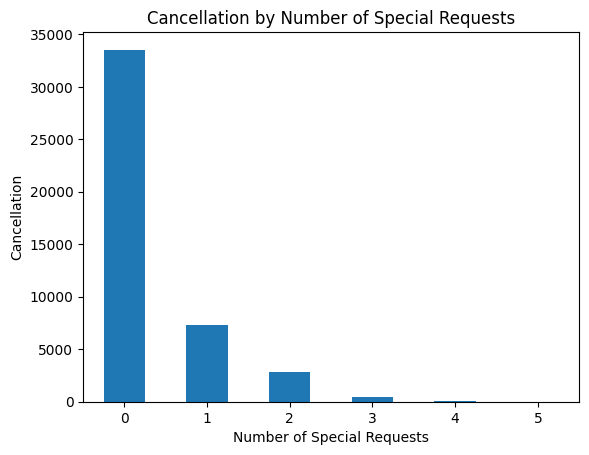

In [ ]:
# graph 10
# Lets look closer at the customer behavior by graphing special requests vs cancellations
# this might be interesting as it would show whether people with more special requests
# are more serious about their booking and less likely to cancel maybe

sc = pd.crosstab(df["total_of_special_requests"], df["is_canceled"])

sc[1].plot(kind = "bar")
plt.title("Cancellation by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation")
plt.xticks(rotation=0)
plt.show()


# **Graph 10 Explanation**
From this graph we can see how the number of special requests relates to cancellations. Furhtermore, we can see that most of the cancellations come from bookings with 0 special requests, and as the number of special requests goes up the cancellations go down.

This is expected and also very interesting at the same time as it confirms that people who make more special requests are less likely to cancel their bookings.

Now, it could be because these customers are more seriuos or more committed to their stay while people with no special requests might not be as sure and end up canceling more.

So it looks like having more special requests is linked to a lower chance of cancellation.

In [ ]:
# NOW that we visualized some heavy parameters against our target
# we can get into modelling, lets prepare the data

#these columns basically give away the answer, so we not gonna use them
df = df.drop(columns = ["reservation_status", "reservation_status_date"] )

#now X is everything that we USE to predict, so everything but is_cancelled dropped
X = df.drop("is_canceled", axis = 1)

# then y is the thing we trynna predict
y = df["is_canceled"]

# we also gotta turn the text columns into numbers
X = pd.get_dummies(X)

# splitting the data into training and testing data
# lets just split it 80 percent for trainsing and 20 percent for testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 40)

# double checking the size of the training and testing data
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (95366, 255)
Testing data: (23842, 255)


# **Preparing Model Explanation**

Before building the models i had to prepare the dataset so it actually works for modeling. First i removed the columns reservation_status and reservation_status_date because they basically tell you directly if a booking was canceled or not, which would make the model unfair and kinda pointless.

Then I split the dataset into features (X) and the target variable (y) where is_canceled is what im trying to predict. Furthermore as the models cant really handle text data directly, i converted all the terxt columns into numbers using one hot encoding.

Finally I split the data into training and testing sets, using 80% for training and 20% for testing. This way the model learns from the training data and then gets tested on new unseen data for out of sample predictions.

In [ ]:
# Lets do Logistic Regression for the first model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# create the model
model1 = LogisticRegression(max_iter = 1000)

# train the model
model1.fit( X_train, y_train)

# mke predictions
y_pred1 = model1.predict(X_test)

# check accuracy
score1 = accuracy_score(y_test, y_pred1)
print("logistic regression accuracy:", score1)

logistic regression accuracy: 0.806224310041104


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **Model 1: Logistic Regression**

For the first model i used logistic regression. Logistic regression is a classification model that predicts the probability of something happening, in this case whether a booking will be canceled or not.

Furthermore, the model got an accuracy of about 80.62% which means it correctly predicted the cancelation outcome for around 81 percent of the test data.

Therfore, it did do a good job at predicting whether a booking would be canceled or not

In [ ]:
# now lets build the second model
# Model 2 with decision tree
from sklearn.tree import DecisionTreeClassifier

# create the model
model2 = DecisionTreeClassifier(random_state = 40)

# train the model
model2.fit(X_train, y_train)

# make predictions
y_pred2 = model2.predict(X_test)

# check accuracy
score2 = accuracy_score(y_test, y_pred2)
print("decision tree accuracy:", score2)

decision tree accuracy: 0.8632665044878786


# **Model 2: Decision Tree**
For the second model I used a decision tree classifier which basically works by splitting the data into branches based on different conditions, so it makes decisions step by step kinda like yes or no paths.

Furthermore, this model got an accuracy of about 86.33 percent which is higher than the logistic regression model, so this shows that the decision tree was better at picking up patterns in the data and predicting whether a booking would be canceled or not.

So it performed better than the first model and handled the data a bit more effectively.

In [ ]:
# we now build the third model
# Model 3 with K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# create the model
model3 = KNeighborsClassifier(n_neighbors = 5)

# train the model
model3.fit(X_train, y_train)

# make predictions
y_pred3 = model3.predict(X_test)

# check accuracy
score3 = accuracy_score(y_test, y_pred3)

print("knn accuracy:", score3)

knn accuracy: 0.7792131532589548


# **Model 3: K Nearest Neighbors**
For the third model I used the k nearest neighbors classifier. KNN works by looking at the closest data points, know as neighbors and then predicting based on the majority class among them.

Furthermore, this model got an accuracy of about 77.92 percent which is lower than both logistic regression and the decision tree, so this shows that KNN wasnt as effective for this dataset, maybe because there are a lot of features and the data is kinda complex.

Eitehr way, it didnt perform as well as the other models and struggled more with making accurate predictions, but still decent enough to consider.

In [ ]:
# now lets check more than just accuracy
# accuracy alone doesnt tell the full story
# lets also check the recall, precision, f-score for all the models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# logistic
acc1 = accuracy_score(y_test, y_pred1)
prec1 = precision_score(y_test, y_pred1)
rec1 = recall_score(y_test, y_pred1)
f11 = f1_score(y_test, y_pred1)

# decision tree
acc2 = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2)
rec2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)

# knn
acc3 = accuracy_score(y_test, y_pred3)
prec3 = precision_score(y_test, y_pred3)
rec3 = recall_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3)


In [ ]:
print("Logistic:")
print(acc1, prec1, rec1, f11)

Logistic:
0.806224310041104 0.789774310392867 0.6456719817767653 0.7104900363454066


In [ ]:
print("Decision Tree:")
print(acc2, prec2, rec2, f12)

Decision Tree:
0.8632665044878786 0.8090705487122061 0.8228929384965832 0.8159232072275551


In [ ]:
print("KNN:")
print(acc3, prec3, rec3, f13)

KNN:
0.7792131532589548 0.7188200149365198 0.657744874715262 0.6869275603663614


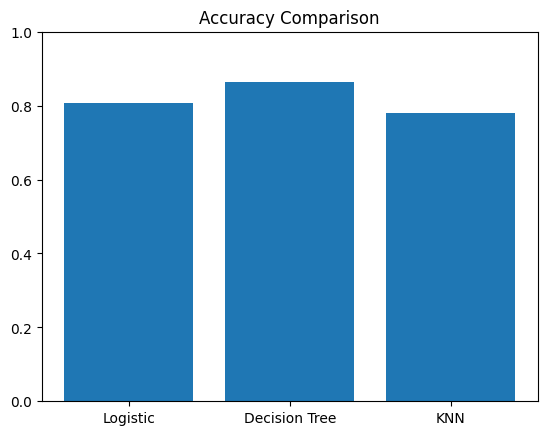

In [ ]:
#make graphs for teh accuracy
models = ["Logistic", "Decision Tree", "KNN"]
accuracy = [acc1, acc2, acc3]
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.ylim(0,1)
plt.show()

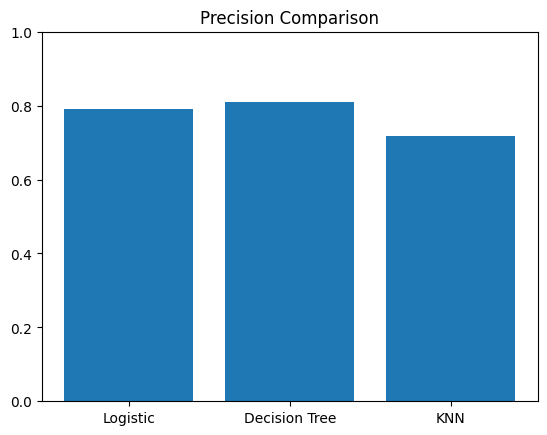

In [ ]:
# Now the precision graph
precision = [prec1, prec2, prec3]

plt.bar(models, precision)
plt.title("Precision Comparison")
plt.ylim(0,1)
plt.show()

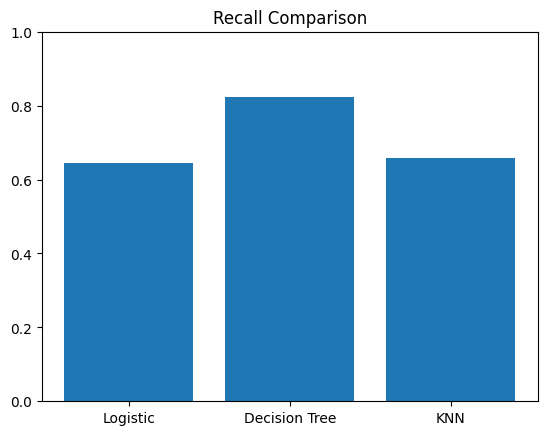

In [ ]:
# recall graph
recall = [rec1, rec2, rec3]

plt.bar(models, recall)
plt.title("Recall Comparison")
plt.ylim(0,1)
plt.show()

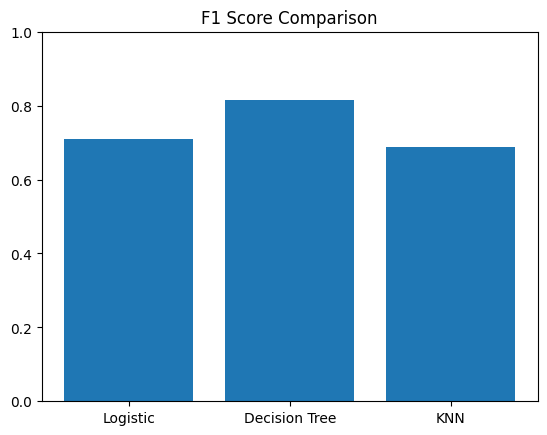

In [ ]:
#graph fo f1 score
f1 = [f11, f12, f13]

plt.bar(models, f1)
plt.title("F1 Score Comparison")
plt.ylim(0,1)
plt.show()

# **Accuracy Metrics Explanation**

After evaluating all three models using accuracy, precision, recall, and F1 score we can compare how all these models actually performed.

The decision tree model clearly did the best across all the metrics, it had the highest accuracy, precision, recall, and F1 score.

Furtrhermore, logistic regression did pretty good but was still a bit lower than the decision tree in every category.

Finally the KNN had the weakest performance out of the three, especially when it comes to precision and F1 score.

So this basically shows that the decision tree was better at capturing patterns in the dataset and making more accurate predictions. Moreover, logistic regression was still a good baseline model, but KNN struggled more, probably because the dataset has a lot of features and is more complex so it doesnt work as well with that kind of data.

In [ ]:
# cross validation: splitting the training data further into validation set
# so now instead of just train/test we have train/validation/test
# we use a built in library, cross_val_score, to do so.
from sklearn.model_selection import cross_val_score

# letsr run 5 fold cross validation on all 3 models
# this basically splits the training data into 5 parts and tests each model 5 times
cv_score1 = cross_val_score(model1, X_train, y_train, cv = 5, scoring = "accuracy")
cv_score2 = cross_val_score(model2, X_train, y_train, cv = 5, scoring = "accuracy")
cv_score3 = cross_val_score(model3, X_train, y_train, cv =5, scoring ="accuracy")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
print("Logistic Regression CV scores:", cv_score1)
print("Logistic Regression CV mean:", cv_score1.mean())

Logistic Regression CV scores: [0.80816819 0.80957374 0.80663766 0.80417344 0.80537933]
Logistic Regression CV mean: 0.8067864712610806


In [ ]:
print("Decision Tree CV scores:", cv_score2)
print("Decision Tree CV mean:", cv_score2.mean())

Decision Tree CV scores: [0.85225962 0.85843863 0.85576469 0.85602684 0.85419179]
Decision Tree CV mean: 0.855336315633404


In [ ]:
print("KNN CV scores:", cv_score3)
print("KNN CV mean:", cv_score3.mean())

KNN CV scores: [0.77246514 0.7769622  0.77397368 0.77649033 0.77014628]
KNN CV mean: 0.774007524090224


# **Cross Validation Explanation**

To further evaluate the models I used 5 fold cross validation on the training data. This basically means the data gets split into 5 parts (k-1/kth parts) and the model is trained and tested multiple times so we get a more reliable idea of how it performs.

Moreover, the logistic regression model had an average score of about 0.807 which is almost the same as its test accuracy Furthermore, the decision tree had the highest average score at around 0.855 which confirms that it consistently performs the best. And the KNN model had the lowest average score at around 0.774

Furthermore, these results match what we saw earlier where the decision tree outperformed the other models. we clearly see that the cross validation scores were very close to the original test scores for all three models, so it didnt really improve performance but it did confirm that the models are consistent and not overfitting.

Therefore, the cross validation shows that the decision tree is better and is more reliable for predicting booking cancellations compared to the other models.

# **Conclusion**

In this project I explroed and analyzed a hotel booking dataset to understand what factors affect booking cancelations.

After cleaning the data and making visualizations i was able to find some important pattrens like higher cancellation rates in city hotels, more cancellations during peak months, and how things like lead time and customer behavior affect cancellations.

Furthermore, I built three machine learning models which were logistic regression, decision tree, and KNN. After evaluating them using accuracy, precision, recall, and F1 score, the decision tree performed the best across all metrics. This shows that it was better at capturing patterns in the dasaset compared to the other models.

Nonetheless, this project shows that machine learning can be used to predict hotel booking cancellations with a pretty good level of accuracy, and that factors for example lead time, deposit type, customer behavior and others play a big role in these predictions.

**Contributor**

Abrar Alam: Worked on the project independently